# OVF region segmentation and Pyramid plotting

This notebook keeps the naming/output style close to `main.ipynb` and `Tg_result.ipynb`.

Run cells step by step: load OVF -> create `mask_inner/mask_outer` -> build `magdata_skyr/magdata_edge` -> plot each region.

In [1]:
import sys
# If Pyramid is not in your current environment, uncomment and edit this line:
# sys.path.extend(['/Users/fzheng/SkyDrive/Codes/Python/Pyramid'])
print('Python %s on %s' % (sys.version, sys.platform))

Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pyramid as pr
import os
import copy
import h5py
from scipy.ndimage import gaussian_filter

pr.plottools.pretty_plots()

## Path and parameters

In [3]:
pathname = '/home/zhaoy/studio/target-skyrmion/zheng_pmdata/zfs_refin_pm/targetmm/sim_SD'
filename = '/m_00003817'
path = pathname + filename

target_mz = -0.9
smoothing_sigma = 3.0
R_conf = 50
rotate_mask_180 = False  # True: use the 180-degree xy mask rotation from main.ipynb

angle = (0+180, 180-28, 180-44, 180-50, 180-54, 180-58, 180-61, 180-65)
angles = np.deg2rad(angle)
angle_labels = [0, 28, 44, 50, 54, 58, 61, 65]

dirs = {
    'orig': 'hdf5/original',
    'skyr': 'hdf5/skyr',
    'edge': 'hdf5/edge',
    'mask': 'hdf5/mask'
}
for d in dirs.values(): os.makedirs(d, exist_ok=True)

## Helper functions

In [ ]:
def get_magdata_field(magdata):
    field = np.asarray(magdata.field)
    if field.ndim != 4:
        raise ValueError('magdata.field should be 4D, but received {}'.format(field.shape))
    if field.shape[0] == 3:
        return field
    if field.shape[-1] == 3:
        return np.moveaxis(field, -1, 0)
    raise ValueError('Cannot find vector component axis in magdata.field: {}'.format(field.shape))

def restore_magdata_field(magdata, field):
    field0 = np.asarray(magdata.field)
    if field0.shape[0] == 3:
        return field
    if field0.shape[-1] == 3:
        return np.moveaxis(field, 0, -1)
    return field

def get_masked_magdata(magdata, mask):
    field = get_magdata_field(magdata)
    field_masked = field * mask[np.newaxis, ...]
    magdata_new = copy.deepcopy(magdata)
    try:
        magdata_new.field = restore_magdata_field(magdata, field_masked)
    except Exception:
        magdata_new = pr.VectorData(magdata.a, field_masked)
    return magdata_new

def create_skyrmion_mask_and_vtk(magdata,
                                 target_mz=-0.9,
                                 smoothing_sigma=3.0,
                                 R_conf=50,
                                 output_filename=None,
                                 rotate_mask_180=False):
    spin = get_magdata_field(magdata)
    if spin.shape[0] != 3:
        raise ValueError('The data shape must be (3, nz, ny, nx), but received {}'.format(spin.shape))

    _, nz, ny, nx = spin.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    print('data parameter: nx={}, ny={}, nz={}'.format(nx, ny, nz))

    if R_conf is None:
        R_conf = min(cx, cy)

    num_angles = 720
    boundary_radii = np.full((nz, num_angles), np.nan)

    def find_boundary_radius_for_slice(k):
        mz_slice = spin[2, k, :, :]
        radii_k = np.full(num_angles, np.nan)
        max_r_step = int(np.ceil(R_conf))

        for i in range(num_angles):
            theta = 2 * np.pi * i / num_angles
            cos_a, sin_a = np.cos(theta), np.sin(theta)
            zero_crossings_r = []
            mz_prev = mz_slice[int(round(cy)), int(round(cx))]

            for r in range(1, max_r_step + 1):
                x_pos, y_pos = cx + r * cos_a, cy + r * sin_a
                ix, iy = int(round(x_pos)), int(round(y_pos))
                if not (0 <= ix < nx and 0 <= iy < ny):
                    break

                mz_current = mz_slice[iy, ix]
                if np.sign(mz_current - target_mz) != np.sign(mz_prev - target_mz):
                    if (mz_current - mz_prev) != 0:
                        r_exact = r - 1 + abs(target_mz - mz_prev) / abs(mz_current - mz_prev)
                        if r_exact <= R_conf:
                            zero_crossings_r.append(r_exact)
                            if len(zero_crossings_r) == 2:
                                break
                mz_prev = mz_current

            if len(zero_crossings_r) >= 2:
                radii_k[i] = (zero_crossings_r[0] + zero_crossings_r[1]) / 2.0

        return radii_k

    def fill_intra_slice_nans(radii_arr):
        nan_indices = np.isnan(radii_arr)
        if np.any(nan_indices):
            if np.all(nan_indices):
                radii_arr[:] = 0.0
            else:
                mean_val = np.nanmean(radii_arr)
                radii_arr[nan_indices] = mean_val
        return radii_arr

    mid_z = nz // 2
    print('Processing center slice: {}'.format(mid_z))
    center_radii = find_boundary_radius_for_slice(mid_z)
    boundary_radii[mid_z, :] = fill_intra_slice_nans(center_radii)

    for k in range(mid_z + 1, nz):
        current_radii = find_boundary_radius_for_slice(k)
        prev_radii = boundary_radii[k - 1, :]
        boundary_radii[k, :] = np.where(np.isnan(current_radii), prev_radii, current_radii)

    for k in range(mid_z - 1, -1, -1):
        current_radii = find_boundary_radius_for_slice(k)
        prev_radii = boundary_radii[k + 1, :]
        boundary_radii[k, :] = np.where(np.isnan(current_radii), prev_radii, current_radii)

    if smoothing_sigma > 0:
        smooth_boundary_radii = gaussian_filter(boundary_radii, sigma=smoothing_sigma, mode='nearest')
    else:
        smooth_boundary_radii = boundary_radii

    jj, ii = np.mgrid[0:ny, 0:nx]
    distance_from_center = np.sqrt((ii - cx)**2 + (jj - cy)**2)
    angle_from_center = np.arctan2(jj - cy, ii - cx)
    angle_indices = np.round((angle_from_center + np.pi) / (2 * np.pi) * (num_angles - 1)).astype(int)
    angle_indices = np.clip(angle_indices, 0, num_angles - 1)

    distance_field_np = np.zeros((nz, ny, nx), dtype=np.float32)
    for k in range(nz):
        boundary_radii_slice = smooth_boundary_radii[k, angle_indices]
        distance_field_np[k, :, :] = distance_from_center - boundary_radii_slice

    distance_field_np = gaussian_filter(distance_field_np, sigma=1.5)

    if rotate_mask_180:
        distance_field_np = np.rot90(distance_field_np, k=2, axes=(1, 2))

    mask_inner = distance_field_np < 0.0

    if output_filename:
        np.save(output_filename, distance_field_np.astype(np.float32))

    return mask_inner, smooth_boundary_radii

def create_phasemaps(magdata, dim_padding=54):
    projectors = []
    dim_uv = (magdata.dim[2] + dim_padding, magdata.dim[1] + dim_padding)
    for theta in angles:
        projectors.append(pr.XTiltProjector(magdata.dim, theta, dim_uv))

    phasemaps = []
    for projector in projectors:
        mag_proj = projector(magdata)
        phasemap = pr.PhaseMapperRDFC(pr.Kernel(magdata.a, projector.dim_uv))(mag_proj)
        phasemap.mask = mag_proj.get_mask()[0, ...]
        phasemaps.append(phasemap)

    data = pr.DataSet(magdata.a, magdata.dim)
    data.append(phasemaps, projectors)
    return phasemaps, projectors, data

def save_phasemaps_hdf5(phasemaps, folder):
    for phasemap, angle0 in zip(phasemaps, angle_labels):
        save_path = os.path.join(folder, 'phase_{:g}.hdf5'.format(angle0))
        with h5py.File(save_path, 'w') as hf:
            hf.create_dataset('phase', data=phasemap.phase.astype(np.float32))

## Load OVF

In [7]:
magdata = pr.load_vectordata('{}.ovf'.format(path))
print(magdata.dim)

(110, 136, 136)


## Create mask_inner and mask_outer

In [8]:
mask_inner, boundary_radii = create_skyrmion_mask_and_vtk(
    magdata,
    target_mz=target_mz,
    smoothing_sigma=smoothing_sigma,
    R_conf=R_conf,
    output_filename=None,
    rotate_mask_180=rotate_mask_180
)
mask_outer = ~mask_inner

np.save(os.path.join(dirs['mask'], 'mask_inner.npy'), mask_inner.astype(np.uint8))
np.save(os.path.join(dirs['mask'], 'boundary_radii.npy'), boundary_radii.astype(np.float32))

data parameter: nx=136, ny=136, nz=110
Processing center slice: 55


## Check middle-slice mask

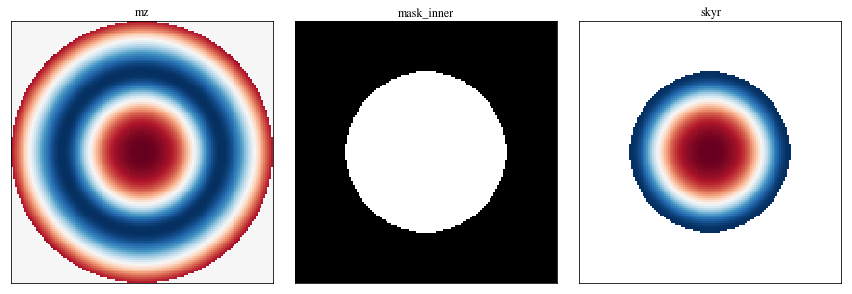

In [9]:
spin = get_magdata_field(magdata)
mz = spin[2]
k = mz.shape[0] // 2

fig = plt.figure(figsize=(12, 4))
ax = {}
ax[1] = fig.add_subplot(1, 3, 1, aspect='equal')
ax[1].imshow(mz[k], cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_title('mz')

ax[2] = fig.add_subplot(1, 3, 2, aspect='equal')
ax[2].imshow(mask_inner[k], cmap='gray', vmin=0, vmax=1)
ax[2].set_title('mask_inner')

ax[3] = fig.add_subplot(1, 3, 3, aspect='equal')
ax[3].imshow(np.where(mask_inner[k], mz[k], np.nan), cmap='RdBu_r', vmin=-1, vmax=1)
ax[3].set_title('skyr')

for i in [1, 2, 3]:
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)

plt.tight_layout(h_pad=0.4)
plt.savefig(os.path.join(dirs['mask'], 'mask_check.png'), dpi=300, bbox_inches='tight')
plt.show()

## Split magdata into skyr and edge

In [10]:
magdata_skyr = get_masked_magdata(magdata, mask_inner)
magdata_edge = get_masked_magdata(magdata, mask_outer)

## Plot original region

/home/zhaoy/anaconda3/envs/pyramid/lib/python3.5/site-packages/matplotlib/figure.py:1742: UserWarning: This figure includes Axes that are not compatible with tight_layout, so its results might be incorrect.
  warnings.warn("This figure includes Axes that are not "


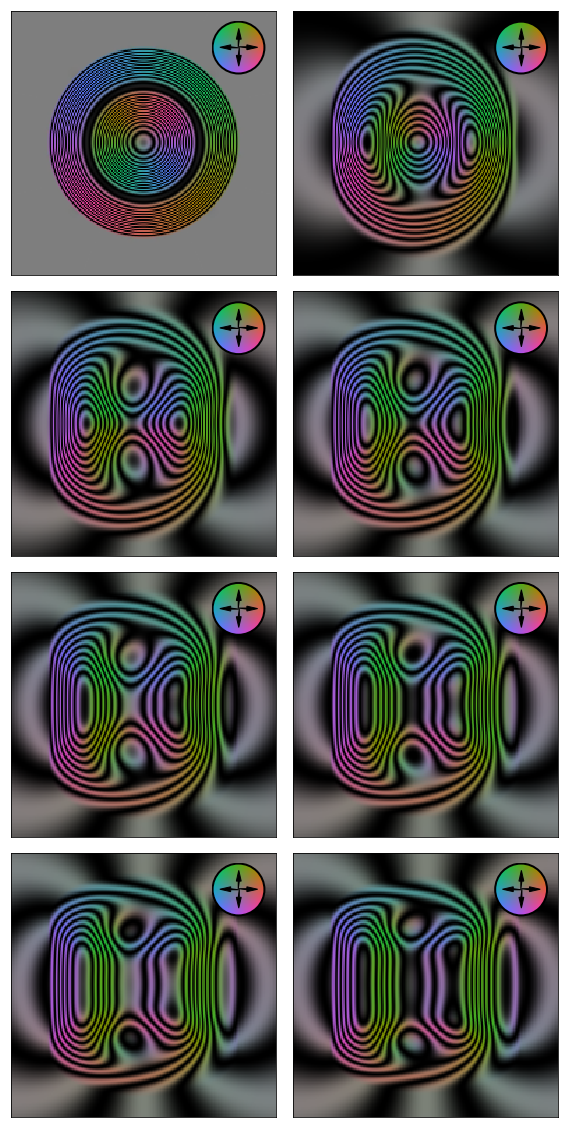

Finished region: orig


In [23]:
phasemaps, projectors, data = create_phasemaps(magdata)
save_phasemaps_hdf5(phasemaps, dirs['orig'])
# plot_phase_panel(phasemaps, projectors, os.path.join(dirs['orig'], 'phase_panel.png'))
fig = plt.figure(figsize=(8, 16))
ax = {}

for i in np.arange(0, 8, 1):
    tilt = np.round(np.rad2deg(projectors[i].tilt))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    phasemaps[i].phase = - phasemaps[i].phase
    #phasemaps[i].plot_holo(axis=ax[i+1], scalebar=False, note=' ', cbar=False, cmap='gray', vmin=-3.5, vmax=0)
    phasemaps[i].plot_holo(axis=ax[i+1],gain=20,scalebar=False,colorwheel=True,note="{}".format(''))
    plt.tight_layout(h_pad=0.4)

fig.savefig(os.path.join(dirs['orig'], 'phase_panel.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Finished region: orig')

## Plot skyr region

In [ ]:
def plot_phase_panel(phasemaps, projectors, save_path, vmin=-0.5, vmax=3.5):
    fig = plt.figure(figsize=(8, 16))
    ax = {}

    for i in np.arange(0, 8, 1):
        tilt = np.round(np.rad2deg(projectors[i].tilt))
        ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
        ax[i+1].get_xaxis().set_visible(False)
        ax[i+1].get_yaxis().set_visible(False)
        phasemaps[i].phase = - phasemaps[i].phase
        phasemaps[i].plot_phase(axis=ax[i+1], scalebar=False, note=' ', cbar=False, cmap='gray', vmin=vmin, vmax=vmax)
        plt.tight_layout(h_pad=0.4)

    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

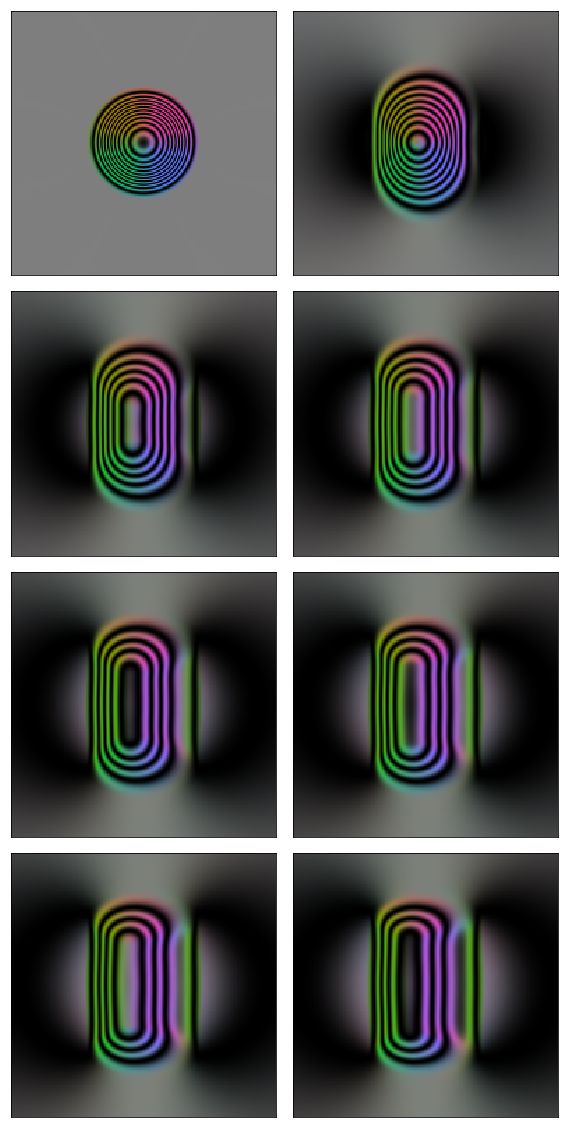

Finished region: skyr


In [31]:
phasemaps, projectors, data = create_phasemaps(magdata_skyr)
save_phasemaps_hdf5(phasemaps, dirs['skyr'])
# plot_phase_panel(phasemaps, projectors, os.path.join(dirs['skyr'], 'phase_panel.png'), vmin=-0.5, vmax=2.5)
fig = plt.figure(figsize=(8, 16))
ax = {}

for i in np.arange(0, 8, 1):
    tilt = np.round(np.rad2deg(projectors[i].tilt))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    phasemaps[i].phase = - phasemaps[i].phase
    #phasemaps[i].plot_holo(axis=ax[i+1], scalebar=False, note=' ', cbar=False, cmap='gray', vmin=-3.5, vmax=0)
    phasemaps[i].plot_holo(axis=ax[i+1],gain=15,scalebar=False,colorwheel=False,note="{}".format(''))
    plt.tight_layout(h_pad=0.4)

fig.savefig(os.path.join(dirs['skyr'], 'phase_panel.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Finished region: skyr')

## Plot edge region

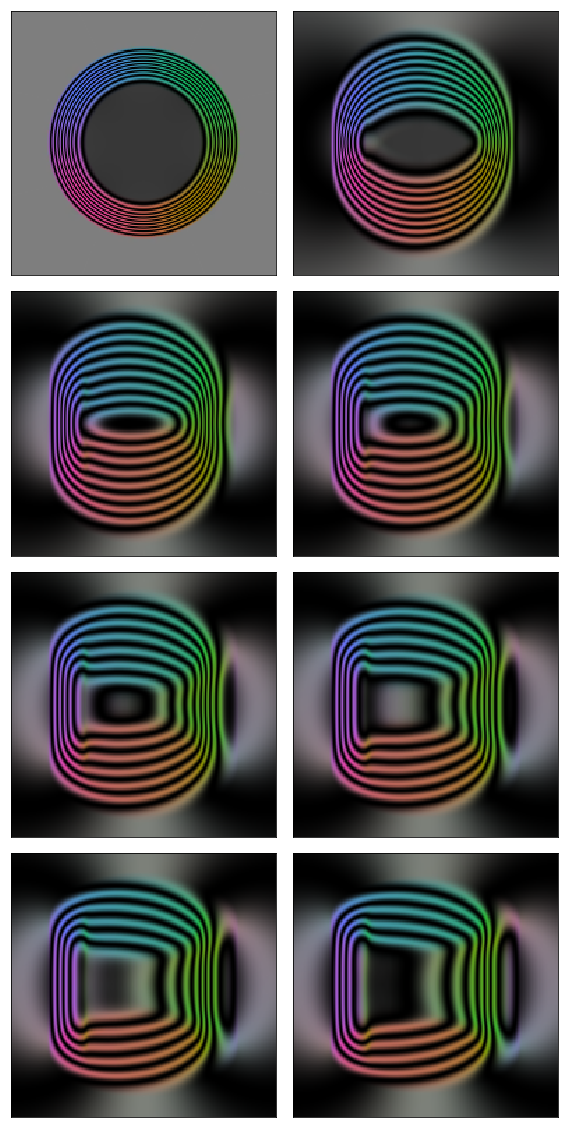

Finished region: edge


In [32]:
phasemaps, projectors, data = create_phasemaps(magdata_edge)
save_phasemaps_hdf5(phasemaps, dirs['edge'])
# plot_phase_panel(phasemaps, projectors, os.path.join(dirs['edge'], 'phase_panel.png'))
fig = plt.figure(figsize=(8, 16))
ax = {}

for i in np.arange(0, 8, 1):
    tilt = np.round(np.rad2deg(projectors[i].tilt))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    phasemaps[i].phase = - phasemaps[i].phase
    #phasemaps[i].plot_holo(axis=ax[i+1], scalebar=False, note=' ', cbar=False, cmap='gray', vmin=-3.5, vmax=0)
    phasemaps[i].plot_holo(axis=ax[i+1],gain=15,scalebar=False,colorwheel=False,note="{}".format(''))
    plt.tight_layout(h_pad=0.4)

fig.savefig(os.path.join(dirs['edge'], 'phase_panel.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Finished region: edge')